# Task 2: Data Acquisition, Inspection and Documentation

This notebook loads and inspects the CDC Diabetes Health Indicators dataset before data cleansing and transformation.

## 2.1 Data acquisition

The CDC Diabetes Health Indicators dataset was obtained from the UCI Machine Learning Repository.

Source: https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators

The dataset originates from the CDC's 2015 Behavioral Risk Factor Surveillance System (BRFSS). The dataset is available under the CC0: Public Domain licence.

The unbalanced binary dataset was selected because it contains all 253,680 survey responses. Its target variable is Diabetes_binary, where 0 represents no diabetes and 1 represents prediabetes or diabetes.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/diabetes_raw.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


## 2.2 Initial data preview

In [2]:
df.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


In [3]:
df.tail()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
253675,1,1,1,45,0,0,0,0,1,1,...,0,3,0,5,0,1,5,6,7,0
253676,1,1,1,18,0,0,0,0,0,0,...,0,4,0,0,1,0,11,2,4,1
253677,0,0,1,28,0,0,0,1,1,0,...,0,1,0,0,0,0,2,5,2,0
253678,1,0,1,23,0,0,0,0,1,1,...,0,3,0,0,0,1,7,5,1,0
253679,1,1,1,25,0,0,1,1,1,0,...,0,2,0,0,0,0,9,6,2,1


In [4]:
rows, columns = df.shape

print("Number of records:", rows)
print("Total number of columns:", columns)
print("Number of predictive features:", columns - 1)
print("Number of target variables: 1")

Number of records: 253680
Total number of columns: 22
Number of predictive features: 21
Number of target variables: 1


### Column names and data types

In [5]:
print("--- Column names ---")
print(df.columns.tolist())

print("\n--- Data types ---")
print(df.dtypes)

--- Column names ---
['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income', 'Diabetes_binary']

--- Data types ---
HighBP                  int64
HighChol                int64
CholCheck               int64
BMI                     int64
Smoker                  int64
Stroke                  int64
HeartDiseaseorAttack    int64
PhysActivity            int64
Fruits                  int64
Veggies                 int64
HvyAlcoholConsump       int64
AnyHealthcare           int64
NoDocbcCost             int64
GenHlth                 int64
MentHlth                int64
PhysHlth                int64
DiffWalk                int64
Sex                     int64
Age                     int64
Education               int64
Income                  int64
Diabetes_binary         int64
dtype: object


All 22 columns are currently stored using the int64 data type. Most variables represent binary or ordinal categories rather than continuous measurements &mdash; for example, HighBP uses 0 for no and 1 for yes &mdash; and four columns (Age, Education, Income, GenHlth) represent ordinal brackets rather than plain counts. These ordinal variables will be converted to a more appropriate categorical data type during data cleansing and transformation (Task 3).

In [6]:
print("--- Missing values ---")
print(df.isna().sum())

print("\nTotal missing values:", df.isna().sum().sum())

--- Missing values ---
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
Diabetes_binary         0
dtype: int64

Total missing values: 0


No missing values were identified. All 22 columns contained complete data for the 253,680 records.

### Duplicate-record inspection

In [7]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = duplicate_count / len(df) * 100

print("Duplicate records:", duplicate_count)
print("Duplicate percentage:", round(duplicate_percentage, 2), "%")

Duplicate records: 24206
Duplicate percentage: 9.54 %


A total of 24,206 records matched an earlier record, representing approximately 9.54% of the dataset. However, the data does not contain a unique participant identifier. Because the features are mostly broad survey categories, separate participants may provide identical responses. These records were documented but not removed during Task 2.

In [8]:
duplicate_records = df[df.duplicated(keep=False)]

duplicate_records.sort_values(
    by=list(df.columns)
).head(10)

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
4517,0,0,0,17,0,0,0,1,1,1,...,0,1,0,0,0,0,8,6,8,0
207307,0,0,0,17,0,0,0,1,1,1,...,0,1,0,0,0,0,8,6,8,0
42369,0,0,0,18,0,0,0,1,1,1,...,0,1,0,0,0,0,10,6,8,0
108949,0,0,0,18,0,0,0,1,1,1,...,0,1,0,0,0,0,10,6,8,0
17475,0,0,0,19,0,0,0,1,1,1,...,0,1,0,0,0,0,4,6,8,0
80704,0,0,0,19,0,0,0,1,1,1,...,0,1,0,0,0,0,4,6,8,0
152374,0,0,0,19,0,0,0,1,1,1,...,0,1,0,0,0,0,4,6,8,0
91414,0,0,0,19,0,0,0,1,1,1,...,0,1,0,0,0,0,6,6,8,0
238843,0,0,0,19,0,0,0,1,1,1,...,0,1,0,0,0,0,6,6,8,0
48850,0,0,0,19,0,0,0,1,1,1,...,0,2,0,0,0,0,9,6,8,0


Examples of repeated records were displayed for inspection. Identical values across all columns do not provide enough evidence to conclude that the records represent the same participant.

### Unique-value inspection

In [9]:
print("--- Number of unique values ---")
print(df.nunique())

--- Number of unique values ---
HighBP                   2
HighChol                 2
CholCheck                2
BMI                     84
Smoker                   2
Stroke                   2
HeartDiseaseorAttack     2
PhysActivity             2
Fruits                   2
Veggies                  2
HvyAlcoholConsump        2
AnyHealthcare            2
NoDocbcCost              2
GenHlth                  5
MentHlth                31
PhysHlth                31
DiffWalk                 2
Sex                      2
Age                     13
Education                6
Income                   8
Diabetes_binary          2
dtype: int64


In [10]:
print("--- Unique values in each column ---")

for col in df.columns:
    values = sorted(df[col].unique().tolist())
    print(col, "->", values)

--- Unique values in each column ---
HighBP -> [0, 1]
HighChol -> [0, 1]
CholCheck -> [0, 1]
BMI -> [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 95, 96, 98]
Smoker -> [0, 1]
Stroke -> [0, 1]
HeartDiseaseorAttack -> [0, 1]
PhysActivity -> [0, 1]
Fruits -> [0, 1]
Veggies -> [0, 1]
HvyAlcoholConsump -> [0, 1]
AnyHealthcare -> [0, 1]
NoDocbcCost -> [0, 1]
GenHlth -> [1, 2, 3, 4, 5]
MentHlth -> [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
PhysHlth -> [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
DiffWalk -> [0, 1]


Sex -> [0, 1]
Age -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Education -> [1, 2, 3, 4, 5, 6]
Income -> [1, 2, 3, 4, 5, 6, 7, 8]
Diabetes_binary -> [0, 1]


The unique values in each column were examined to identify inconsistent categories and invalid entries. The results show that the binary variables contain only 0 and 1, which is consistent with their documented coding.

The ordinal variables also remain within their expected ranges. For example, GenHlth contains categories from 1 to 5, Age contains categories from 1 to 13, Education contains categories from 1 to 6, and Income contains categories from 1 to 8.

BMI, MentHlth and PhysHlth contain a larger number of values because they represent measurements or counts rather than simple categories. No inconsistent category codes were identified during this inspection.

### Summary statistics and value ranges

In [11]:
print("--- Summary statistics ---")
df.describe().T

--- Summary statistics ---


,count,mean,std,min,25%,50%,75%,max
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0
Veggies,253680.0,0.811420,0.391175,0.0,1.0,1.0,1.0,1.0


The summary statistics showed that BMI ranged from 12 to 98, with a mean of approximately 28.38 and a median of 27. GenHlth ranged from 1 to 5, Age from 1 to 13, Education from 1 to 6, and Income from 1 to 8. MentHlth and PhysHlth both ranged from 0 to 30 days. All binary columns had a minimum of 0 and a maximum of 1.

### Invalid and inconsistent value inspection

In [12]:
binary_columns = [
    "HighBP",
    "HighChol",
    "CholCheck",
    "Smoker",
    "Stroke",
    "HeartDiseaseorAttack",
    "PhysActivity",
    "Fruits",
    "Veggies",
    "HvyAlcoholConsump",
    "AnyHealthcare",
    "NoDocbcCost",
    "DiffWalk",
    "Sex",
    "Diabetes_binary"
]

for col in binary_columns:
    bad = df[~df[col].isin([0, 1])]
    print(col, "invalid values:", len(bad))

HighBP invalid values: 0
HighChol invalid values: 0
CholCheck invalid values: 0
Smoker invalid values: 0
Stroke invalid values: 0
HeartDiseaseorAttack invalid values: 0
PhysActivity invalid values: 0
Fruits invalid values: 0
Veggies invalid values: 0
HvyAlcoholConsump invalid values: 0
AnyHealthcare invalid values: 0
NoDocbcCost invalid values: 0
DiffWalk invalid values: 0


Sex invalid values: 0
Diabetes_binary invalid values: 0


In [13]:
range_checks = {
    "GenHlth": (1, 5),
    "MentHlth": (0, 30),
    "PhysHlth": (0, 30),
    "Age": (1, 13),
    "Education": (1, 6),
    "Income": (1, 8)
}

for col, limits in range_checks.items():
    minimum = limits[0]
    maximum = limits[1]

    bad = df[
        (df[col] < minimum) |
        (df[col] > maximum)
    ]

    print(col, "out-of-range records:", len(bad))

GenHlth out-of-range records: 0
MentHlth out-of-range records: 0
PhysHlth out-of-range records: 0
Age out-of-range records: 0
Education out-of-range records: 0
Income out-of-range records: 0


No invalid values were found in the binary or ordinal columns. All checked variables remained within the expected ranges specified in the dataset documentation. No inconsistent text formatting was present because all variables were numerically encoded.

In [14]:
print("--- Lowest BMI values ---")
print(df["BMI"].sort_values().head(10))

print("\n--- Highest BMI values ---")
print(df["BMI"].sort_values(ascending=False).head(20))

--- Lowest BMI values ---


136036    12
98002     12
49827     12
210863    12
177462    12
239607    12
248109    13
208779    13
40601     13
228602    13
Name: BMI, dtype: int64

--- Highest BMI values ---


79554     98
76394     98
79478     98
76532     98
76396     98
79507     98
76370     98
36324     96
76373     95
79418     95
79350     95
79544     95
76527     95
244309    95
76366     95
79492     95
76371     95
79522     95
206389    95
76353     95
Name: BMI, dtype: int64


In [15]:
print("BMI below 15:", len(df[df["BMI"] < 15]))
print("BMI above 60:", len(df[df["BMI"] > 60]))

BMI below 15: 68
BMI above 60: 805


BMI ranged from 12 to 98. Values at both ends of the range are unusual and were identified as potential outliers. However, unusual BMI values are not automatically invalid. They were retained during Task 2 and will be investigated further during data cleansing.

### Target-variable distribution

In [16]:
print("--- Diabetes class counts ---")
print(df["Diabetes_binary"].value_counts())

print("\n--- Diabetes class percentages ---")
print(
    df["Diabetes_binary"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

--- Diabetes class counts ---
Diabetes_binary
0    218334
1     35346
Name: count, dtype: int64

--- Diabetes class percentages ---
Diabetes_binary
0    86.07
1    13.93
Name: proportion, dtype: float64


Approximately 86.07% of participants were labelled as having no diabetes, while 13.93% were labelled as having prediabetes or diabetes. This shows that the target variable is imbalanced.

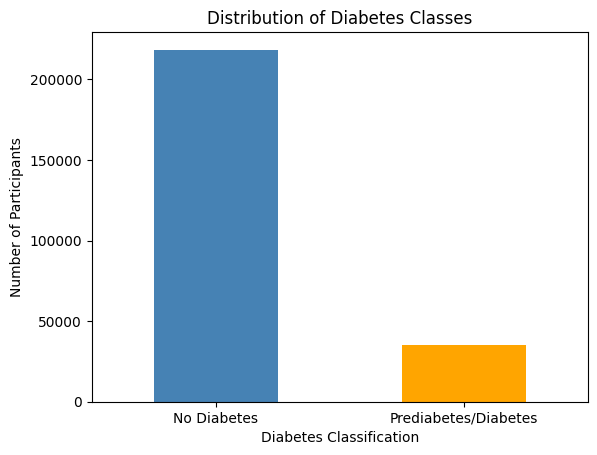

In [17]:
import matplotlib.pyplot as plt

df["Diabetes_binary"].value_counts().sort_index().plot(
    kind="bar",
    color=["steelblue", "orange"]
)

plt.title("Distribution of Diabetes Classes")
plt.xlabel("Diabetes Classification")
plt.ylabel("Number of Participants")
plt.xticks(
    ticks=[0, 1],
    labels=["No Diabetes", "Prediabetes/Diabetes"],
    rotation=0
)

plt.show()

The class-distribution graph shows that the number of participants without diabetes is substantially larger than the number with prediabetes or diabetes. This imbalance will need to be considered during later analysis and modelling.

### Variable meanings

- HighBP: high blood pressure, where 0 = no and 1 = yes.
- HighChol: high cholesterol, where 0 = no and 1 = yes.
- CholCheck: cholesterol check within five years.
- BMI: Body Mass Index.
- Smoker: smoked at least 100 cigarettes during their lifetime.
- Stroke: history of stroke.
- HeartDiseaseorAttack: history of coronary heart disease or heart attack.
- PhysActivity: physical activity during the previous 30 days.
- Fruits: consumes fruit at least once per day.
- Veggies: consumes vegetables at least once per day.
- HvyAlcoholConsump: heavy alcohol consumption.
- AnyHealthcare: has healthcare coverage.
- NoDocbcCost: unable to visit a doctor because of cost.
- GenHlth: general health category from 1 = excellent to 5 = poor.
- MentHlth: number of poor mental-health days in the previous 30 days.
- PhysHlth: number of poor physical-health days in the previous 30 days.
- DiffWalk: serious difficulty walking or climbing stairs.
- Sex: 0 = female and 1 = male.
- Age: age category from 1 to 13.
- Education: education category from 1 to 6.
- Income: income category from 1 to 8.
- Diabetes_binary: 0 = no diabetes and 1 = prediabetes or diabetes.

### Assumptions made during data interpretation

1. Each row represents a separate BRFSS survey participant.
2. Diabetes_binary is the target variable.
3. Binary values are treated as categories rather than numerical measurements.
4. Age, Education, Income and GenHlth are ordered categories.
5. Identical records are not automatically treated as accidental duplicates because no unique participant identifier is available.
6. Extreme BMI values are considered potential outliers rather than confirmed errors.
7. The absence of missing values may be the result of preprocessing performed by the dataset creator.
8. The survey responses are self-reported and may be affected by recall or response bias.
9. The data represents surveyed adults in the United States during 2015 and may not generalise to other countries or populations.